# Analytics Module
The Analytics module provides descriptive statistics on content data, evidence data and model evaluations 

In [2]:
# reloads modules automatically before entering the execution of code
%load_ext autoreload
%autoreload 2

# third parties imports
import numpy as np 
import pandas as pd
# -- add new imports here --
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
# local imports
from constants import Constant as C
from loaders import load_ratings
from loaders import load_items

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1 - Content analytics
Explore and perform descriptive statistics on content data

In [3]:
# -- load the items and display the Dataframe

df_items = load_items()
display(df_items)

,title,genres
movieId,,
4993,"Lord of the Rings: The Fellowship of the Ring,...",Adventure|Fantasy
5952,"Lord of the Rings: The Two Towers, The (2002)",Adventure|Fantasy
527,Schindler's List (1993),Drama|War
2028,Saving Private Ryan (1998),Action|Drama|War
4308,Moulin Rouge (2001),Drama|Musical|Romance
1721,Titanic (1997),Drama|Romance
1997,"Exorcist, The (1973)",Horror|Mystery
1214,Alien (1979),Horror|Sci-Fi
2700,"South Park: Bigger, Longer and Uncut (1999)",Animation|Comedy|Musical


In [4]:
# -- display relevant informations that can be extracted from the dataset

# The number of movies
n_movies = len(df_items)
print(f"Number of movies: {n_movies}")

# Year range 
df_items['year'] = df_items[C.LABEL_COL].str.extract(r'\((\d{4})\)').astype(float)
min_year = df_items['year'].min()
max_year = df_items['year'].max()
print(f"Year range: {int(min_year)} - {int(max_year)}")

# List of unique movie genres
genres_list = df_items[C.GENRES_COL].str.split('|').explode().unique()
print(f"Movie genres: {list(genres_list)}")

Number of movies: 10
Year range: 1973 - 2002
Movie genres: ['Adventure', 'Fantasy', 'Drama', 'War', 'Action', 'Musical', 'Romance', 'Horror', 'Mystery', 'Sci-Fi', 'Animation', 'Comedy', 'Children', 'IMAX']


# 2 - Evidence analytics
Explore and perform descriptive statistics on evidence data

In [5]:
# -- load the items and display the Dataframe

df_ratings = load_ratings()
display(df_ratings)

,userId,movieId,rating,timestamp
0,11,1997,1.5,949810582
1,11,2028,4.0,949919681
2,11,4993,5.0,949919763
3,11,5952,4.5,949919681
4,11,2700,3.0,949949538
5,11,1721,1.0,949895887
6,13,1214,1.0,1154389491
7,13,2028,2.0,1154473252
8,13,5952,2.0,1154400308
9,13,364,5.0,1154400458


In [6]:
# -- display relevant informations that can be extracted from the dataset

# (A) The total number of rating 
total_ratings = len(df_ratings[C.RATING_COL])
print(f"Total number of ratings: {total_ratings}")

# (B) The number of unique users
n_unique_users = df_ratings[C.USER_ID_COL].nunique() 
print(f"Number of unique users: {n_unique_users}")

# (C) The number of unique movies (in the ratings matrix)
n_unique_movies = df_ratings[C.ITEM_ID_COL].nunique() 
print(f"Number of unique movies: {n_unique_movies}")

# (D) The number of ratings of the most rated movie(s) 
# (E) The number of ratings of the less rated movie(s)
ratings_per_movie = df_ratings.groupby(C.ITEM_ID_COL).size()
max_ratings = ratings_per_movie.max()
min_ratings = ratings_per_movie.min()
print(f"Number of ratings of the most rated movie: {max_ratings}")
print(f"Number of ratings of the least rated movie: {min_ratings}")

# (F) All the possible rating values, from smallest value to value highest
rating_values = sorted([float(v) for v in df_ratings[C.RATING_COL].unique()])
print(f"All possible rating values: {rating_values}")

# (G) The number of movies that were not rated at all
catalog_ids = set(df_items.index) 
rated_ids = set(df_ratings[C.ITEM_ID_COL])
not_rated_count = len(catalog_ids - rated_ids)
print(f"Number of movies that were not rated at all: {not_rated_count}")

Total number of ratings: 30
Number of unique users: 6
Number of unique movies: 10
Number of ratings of the most rated movie: 4
Number of ratings of the least rated movie: 2
All possible rating values: [1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 4.5, 5.0]
Number of movies that were not rated at all: 0


# 3 - Long-tail property

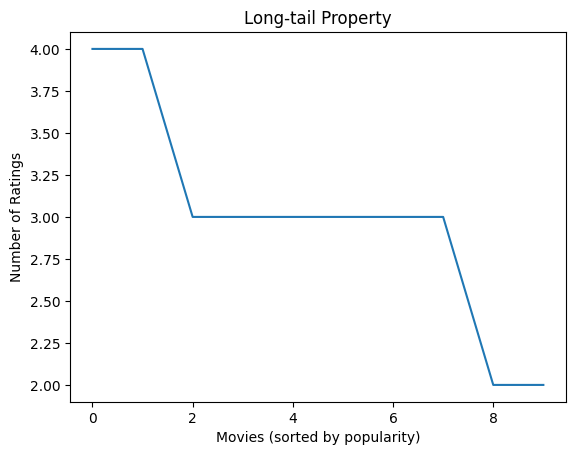

In [7]:
# (1) Count the number of ratings per movie
movie_counts = df_ratings[C.ITEM_ID_COL].value_counts()

# (2) Sort the counts from highest to lowest
sorted_counts = movie_counts.sort_values(ascending=False).values

# (3) Simple plot
plt.plot(sorted_counts)
plt.title("Long-tail Property")
plt.xlabel("Movies (sorted by popularity)")
plt.ylabel("Number of Ratings")
plt.show()

# 4 - Ratings matrix sparsity

Matrix sparsity: 50.0%


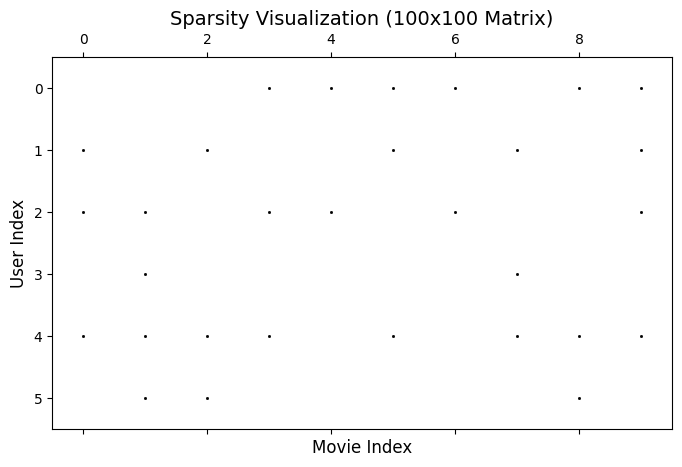

In [8]:
# STEP 1 : Create the Sparse Matrix
def create_X(df):
    M = df[C.USER_ID_COL].nunique()
    N = df[C.ITEM_ID_COL].nunique()

    user_mapper = dict(zip(np.unique(df[C.USER_ID_COL]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df[C.ITEM_ID_COL]), list(range(N))))

    user_inv_mapper = dict(zip(list(range(M)), np.unique(df[C.USER_ID_COL])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df[C.ITEM_ID_COL])))

    user_index = [user_mapper[i] for i in df[C.USER_ID_COL]]
    item_index = [movie_mapper[i] for i in df[C.ITEM_ID_COL]]

    X = csr_matrix((df[C.RATING_COL], (user_index, item_index)), shape=(M, N))

    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

# Generate the matrix using the ratings dataframe
X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df_ratings)


# STEP 2 : Compute Sparsity Metric
n_total = X.shape[0] * X.shape[1]  # Total cells (Users * Movies)
n_ratings = X.nnz                  # Number of specified ratings
sparsity_metric = 1 - (n_ratings / n_total)

print(f"Matrix sparsity: {round(sparsity_metric * 100, 2)}%")


# STEP 3 : Visual Observation with .spy()
# Create the plot
plt.figure(figsize=(8, 8))

# We slice the first 100 rows and 100 columns of X
plt.spy(X[:100, :100], markersize=1, color='black')

plt.title("Sparsity Visualization (100x100 Matrix)", fontsize=14)
plt.xlabel("Movie Index", fontsize=12)
plt.ylabel("User Index", fontsize=12)

plt.show()
